   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 4.8 MB/s eta 0:00:00
--- ՔԱՅԼ 1. ՎԵՐԲԵՌՆԵՔ ՍՈՎՈՐԵԼՈՒ ՖԱՅԼԵՐԸ ---


Saving ԱԿՍԵԼ ԲԱԿՈՒՆՑ ԿԱՐՄՐԱՔԱՐ.docx to ԱԿՍԵԼ ԲԱԿՈՒՆՑ ԿԱՐՄՐԱՔԱՐ.docx
Saving ԵՂԻՇԵ ՉԱՐԵՆՑ ԵՐԿԻՐ ՆԱԻՐԻ ԱԲ.docx to ԵՂԻՇԵ ՉԱՐԵՆՑ ԵՐԿԻՐ ՆԱԻՐԻ ԱԲ.docx
Saving ԽԱՉԱՏՈՒՐ ԱԲՈՎՅԱՆ ՎԵՐՔ ՀԱՅԱՍՏԱՆԻ ԳԼՈՒԽ 1.docx to ԽԱՉԱՏՈՒՐ ԱԲՈՎՅԱՆ ՎԵՐՔ ՀԱՅԱՍՏԱՆԻ ԳԼՈՒԽ 1.docx
Saving ՄՈՒՐԱՑԱՆ ԳևՈՐԳ ՄԱՐԶՊԵՏՈՒՆԻ Ա-Է.docx to ՄՈՒՐԱՑԱՆ ԳևՈՐԳ ՄԱՐԶՊԵՏՈՒՆԻ Ա-Է.docx
Saving ՇԻՐՎԱՆԶԱԴԵ ՉԱՐ ՈԳԻ 1-10.docx to ՇԻՐՎԱՆԶԱԴԵ ՉԱՐ ՈԳԻ 1-10.docx
Saving ՐԱՖՖԻ ԽԵՆԹԸ ՄԻՆՉև ԺԷ.docx to ՐԱՖՖԻ ԽԵՆԹԸ ՄԻՆՉև ԺԷ.docx
Մոդելը սովորեցված է հեղինակ 'Բակունց'-ի համար (ԱԿՍԵԼ ԲԱԿՈՒՆՑ ԿԱՐՄՐԱՔԱՐ.docx)
Մոդելը սովորեցված է հեղինակ 'Չարենց'-ի համար (ԵՂԻՇԵ ՉԱՐԵՆՑ ԵՐԿԻՐ ՆԱԻՐԻ ԱԲ.docx)
Մոդելը սովորեցված է հեղինակ 'Աբովյան'-ի համար (ԽԱՉԱՏՈՒՐ ԱԲՈՎՅԱՆ ՎԵՐՔ ՀԱՅԱՍՏԱՆԻ ԳԼՈՒԽ 1.docx)
Մոդելը սովորեցված է հեղինակ 'Մուրացան'-ի համար (ՄՈՒՐԱՑԱՆ ԳևՈՐԳ ՄԱՐԶՊԵՏՈՒՆԻ Ա-Է.docx)
Մոդելը սովորեցված է հեղինակ 'Շիրվանզադե'-ի համար (ՇԻՐՎԱՆԶԱԴԵ ՉԱՐ ՈԳԻ 1-10.docx)
Մոդելը սովորեցված է հեղինակ 'Րաֆֆի'-ի համար (ՐԱՖՖԻ ԽԵՆԹԸ ՄԻՆՉև ԺԷ.docx)

--- ՔԱՅԼ 2. ՎԵՐԲԵՌՆԵՔ ԲՈԼՈՐ ՍՏՈՒԳՎՈՂ ՖԱՅԼԵՐԸ ---


Saving Ալինա 1-6.docx to Ալինա 1-6.docx
Saving Առաջին սերը.docx to Առաջին սերը.docx
Saving Երևանի ուղղիչ տնից 2-6.docx to Երևանի ուղղիչ տնից 2-6.docx
Saving Խաչագողի հիշատակարանը Ա.docx to Խաչագողի հիշատակարանը Ա.docx
Saving Կյորես.docx to Կյորես.docx
Saving Նոյի ագռավ.docx to Նոյի ագռավ.docx

--- ՎԵՐՋՆԱԿԱՆ ԱՂՅՈՒՍԱԿ (COMBINED MODEL) ---


,Ֆայլ,Բակունց,Չարենց,Աբովյան,Մուրացան,Շիրվանզադե,Րաֆֆի,Կանխատեսում
0,Ալինա 1-6.docx,-2.664425,-2.646899,-2.803393,-2.653825,-2.640391,-2.641826,Շիրվանզադե
1,Առաջին սերը.docx,-2.701260,-2.746988,-2.608697,-2.864846,-2.808112,-2.809077,Աբովյան
2,Երևանի ուղղիչ տնից 2-6.docx,-2.650044,-2.634512,-2.768192,-2.676047,-2.672521,-2.652093,Չարենց
3,Խաչագողի հիշատակարանը Ա.docx,-2.603718,-2.599594,-2.704810,-2.609396,-2.593497,-2.567038,Րաֆֆի
4,Կյորես.docx,-2.636777,-2.656984,-2.766128,-2.735102,-2.682445,-2.663149,Բակունց
5,Նոյի ագռավ.docx,-2.635137,-2.609516,-2.766568,-2.614225,-2.630739,-2.602951,Րաֆֆի


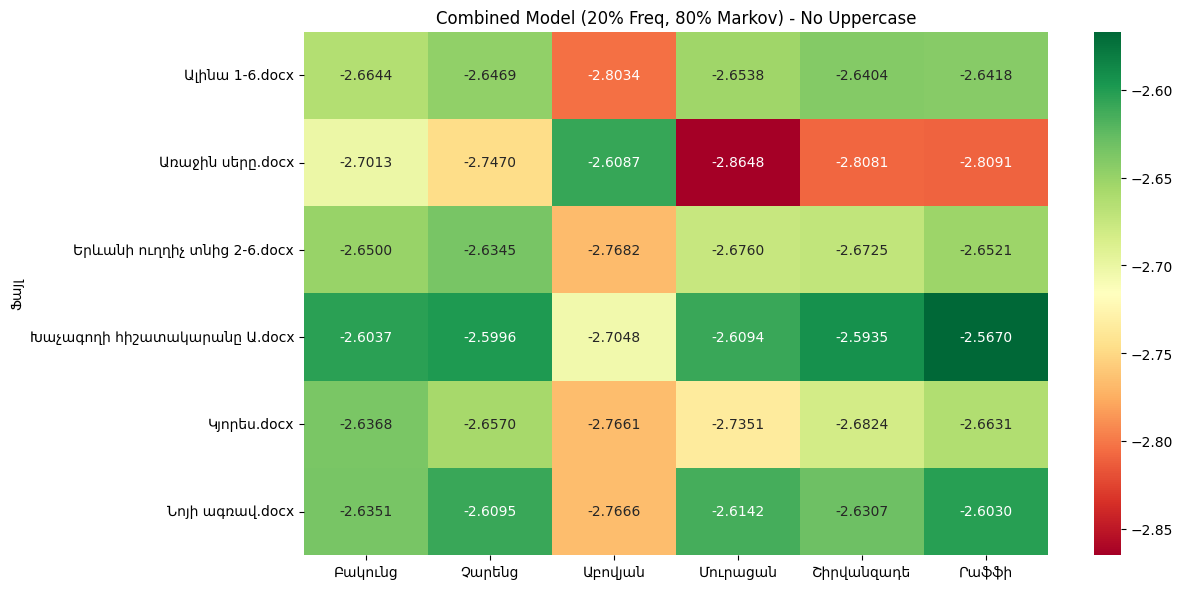

In [1]:
import math
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import files
!pip install python-docx
from docx import Document

# =========================
# ԿԱՐԳԱՎՈՐՈՒՄՆԵՐ
# =========================
alphabet = ' աբգդեզէըթժիլխծկհձղճմյնշոչպջռսվտրցւփքևօֆ'
n, alpha = len(alphabet), 1e-4
authors_to_find = ["Աբովյան", "Րաֆֆի", "Բակունց", "Շիրվանզադե", "Չարենց", "Մուրացան"]

def read_docx(filename):
    return " ".join([p.text for p in Document(filename).paragraphs])

def text_processing(text):

    tx = text.lower().replace("ու", "ւ").replace("եվ", "և")
    clean = ''.join([x for x in tx if x in alphabet])
    return " " + " ".join(clean.split()) + " "

# =========================
# ՄԱԹԵՄԱՏԻԿԱԿԱՆ ՄՈԴԵԼՆԵՐ
# =========================

def get_freq_model(text):
    N = len(text)
    return [(text.count(ch) + alpha) / (N + alpha * n) for ch in alphabet]

def transition_matrix(text):
    pair, row_sums = [[0]*n for _ in range(n)], [0]*n
    for k in range(len(text)-1):
        idx1, idx2 = alphabet.index(text[k]), alphabet.index(text[k+1])
        pair[idx1][idx2] += 1
        row_sums[idx1] += 1
    return [[(pair[i][j] + alpha) / (row_sums[i] + alpha * n) for j in range(n)] for i in range(n)]

def get_combined_score(test_text, model_freq, model_markov):
    if len(test_text) < 2: return -1e10

    # 1. Frequency Score
    f_score = sum(math.log(model_freq[alphabet.index(ch)]) for ch in test_text) / len(test_text)

    # 2. Markov Score
    m_log_L = 0
    for k in range(len(test_text)-1):
        idx1, idx2 = alphabet.index(test_text[k]), alphabet.index(test_text[k+1])
        m_log_L += math.log(model_markov[idx1][idx2])
    m_score = m_log_L / (len(test_text)-1)

    # 3. Combined (20% Freq + 80% Markov)
    return 0.2 * f_score + 0.8 * m_score

# =========================
# ՔԱՅԼ 1. ՍՈՎՈՐԵՑՄԱՆ ՓՈՒԼ
# =========================
print("--- ՔԱՅԼ 1. ՎԵՐԲԵՌՆԵՔ ՍՈՎՈՐԵԼՈՒ ՖԱՅԼԵՐԸ ---")
uploaded_train = files.upload()

freq_models = {}
markov_models = {}

for filename in uploaded_train.keys():
    for auth in authors_to_find:
        if auth.lower() in filename.lower():
            text = text_processing(read_docx(filename))
            freq_models[auth] = get_freq_model(text)
            markov_models[auth] = transition_matrix(text)
            print(f"Մոդելը սովորեցված է հեղինակ '{auth}'-ի համար ({filename})")

# =========================
# ՔԱՅԼ 2. ԹԵՍՏԱՎՈՐՄԱՆ ՓՈՒԼ
# =========================
print("\n--- ՔԱՅԼ 2. ՎԵՐԲԵՌՆԵՔ ԲՈԼՈՐ ՍՏՈՒԳՎՈՂ ՖԱՅԼԵՐԸ ---")
uploaded_tests = files.upload()

all_results = []

for test_filename in uploaded_tests.keys():
    test_text = text_processing(read_docx(test_filename))
    res_row = {'Ֆայլ': test_filename}

    scores_for_selection = {}
    for auth in freq_models.keys():
        score = get_combined_score(test_text, freq_models[auth], markov_models[auth])
        res_row[auth] = score
        scores_for_selection[auth] = score

    # Գտնում ենք առավելագույն միավորով հեղինակին
    res_row['Կանխատեսում'] = max(scores_for_selection, key=scores_for_selection.get)
    all_results.append(res_row)

# =========================
# ՔԱՅԼ 3. ԱՐԴՅՈՒՆՔՆԵՐԻ ՎԻԶՈՒԱԼԻԶԱՑԻԱ
# =========================
df_res = pd.DataFrame(all_results)
print("\n--- ՎԵՐՋՆԱԿԱՆ ԱՂՅՈՒՍԱԿ (COMBINED MODEL) ---")
display(df_res)

# Heatmap-ի կառուցում
heatmap_df = df_res.set_index('Ֆայլ').drop(columns=['Կանխատեսում'])
plt.figure(figsize=(12, len(all_results) * 0.8 + 2))
sns.heatmap(heatmap_df, annot=True, cmap="RdYlGn", fmt=".4f")
plt.title("Combined Model (20% Freq, 80% Markov) - No Uppercase")
plt.show()